### Boundary Value Problem (BVP) Conditions and Domain

In this problem, we are solving a second-order ordinary differential equation (ODE):

$$- \frac{d^2u}{dt^2} + \pi^2 u - 2\pi \sin(\pi t) = 0$$

The **domain** for this problem is $t \in [0, 1]$. This means we are looking for a solution $u(t)$ that is defined and satisfies the ODE within this interval.

To uniquely determine the solution of a second-order ODE, we need two **boundary conditions**. In this specific BVP, these conditions are given at the boundaries of the domain ($t=0$ and $t=1$):

1.  **Dirichlet Boundary Conditions (Value at boundaries):**
    *   $u(0) = 0$
    *   $u(1) = 0$

2.  **Neumann Boundary Conditions (Derivative at boundaries):**
    *   $u'(0) = \pi$
    *   $u'(1) = -\pi$
2.  **Exact Solution:**
     $u(t) = sin(πx)$

In [18]:
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt

pi = jnp.pi

In [19]:
def init_mlp(layers, key):
    params = []
    keys = jax.random.split(key, len(layers)-1)

    for k, (m, n) in zip(keys, zip(layers[:-1], layers[1:])):
        W = jax.random.normal(k, (m, n)) * jnp.sqrt(2/m)
        b = jnp.zeros(n)
        params.append((W, b))

    return params


def mlp(params, x):
    for W, b in params[:-1]:
        x = jnp.tanh(x @ W + b)
    W, b = params[-1]
    return x @ W + b

def u_model(params, x):
    return mlp(params, x.reshape(-1,1)).squeeze()

def u_hard(params, x):
    # Structural guarantee for:
    # u(0)=0, u(1)=0, u'(0)=pi, u'(1)=-pi
    # term1 provides the required values and slopes at 0 and 1
    term1 = jnp.pi * x * (1.0 - x)

    # term2 vanishes (value and slope) at both x=0 and x=1
    # because of the x^2 * (1-x)^2 factor
    nn_output = u_model(params, x).squeeze()
    term2 = (x**2) * ((1.0 - x)**2) * nn_output

    return term1 + term2

In [20]:
def dudx(params, x):
    return jax.grad(lambda z: u_hard(params, z))(x)

def d2udx2(params, x):
    return jax.grad(lambda z: dudx(params, z))(x)

def residual(params, x):
    # Using the hard-embedded solution in the ODE residual
    return -d2udx2(params, x) + jnp.pi**2 * u_hard(params, x) - 2 * jnp.pi**2 * jnp.sin(jnp.pi * x)

In [21]:
def loss_fn(params, xs):
    # The network now only learns the interior residual
    res = jax.vmap(lambda x: residual(params, x))(xs)
    return jnp.mean(res**2)

| iteration= 0   |   loss= 24.423794   |   l1_error= 0.13674453
| iteration= 500   |   loss= 0.04724055   |   l1_error= 0.00095608324
| iteration= 1000   |   loss= 0.012607321   |   l1_error= 0.00051081175
| iteration= 1500   |   loss= 0.0037889956   |   l1_error= 0.00020526323
| iteration= 2000   |   loss= 0.0024584658   |   l1_error= 0.00014882917
| iteration= 2500   |   loss= 0.0016471785   |   l1_error= 0.00011600518
| iteration= 3000   |   loss= 0.0010196045   |   l1_error= 8.558229e-05
| iteration= 3500   |   loss= 0.00061768957   |   l1_error= 6.2944164e-05


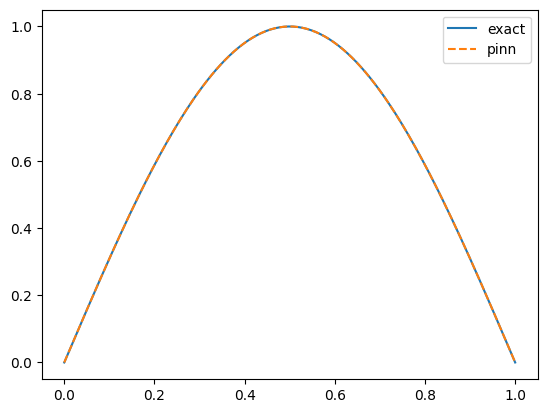

In [22]:
key = jax.random.PRNGKey(0)
params = init_mlp([1, 32, 32, 1], key)

xs = jnp.linspace(0,1,100)
x_plot = jnp.linspace(0,1,200)
u_exact_plot = jnp.sin(pi*x_plot)

opt = optax.adam(1e-3)
opt_state = opt.init(params)

@jax.jit
def step(params, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params, xs)
    updates, opt_state = opt.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

for i in range(4000):
    params, opt_state, loss = step(params, opt_state)
    if i % 500 == 0:
        u_pred_plot = jax.vmap(lambda x: u_hard(params, x))(x_plot)
        l1_error = jnp.mean(jnp.abs(u_pred_plot - u_exact_plot))
        print( "| iteration=",i,  "  |   loss=", loss, "  |   l1_error=", l1_error)

u_pred = jax.vmap(lambda x: u_hard(params, x))(x_plot)
u_exact = jnp.sin(pi*x_plot)

plt.plot(x_plot, u_exact, label="exact")
plt.plot(x_plot, u_pred, "--", label="pinn")
plt.legend()
plt.show()

Inverse Problem

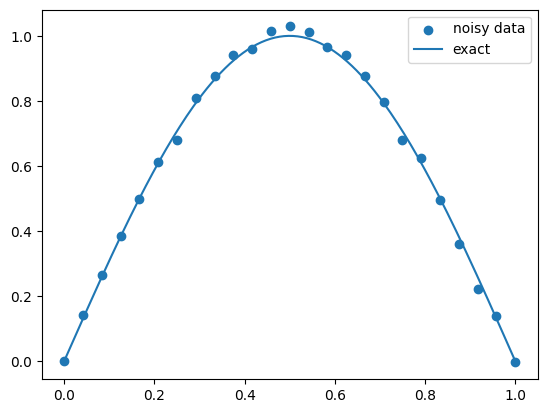

In [23]:
key = jax.random.PRNGKey(42)

n_obs = 25
x_obs = jnp.linspace(0, 1, n_obs)

u_exact_obs = jnp.sin(pi * x_obs)

noise_level = 0.02
noise = noise_level * jax.random.normal(key, x_obs.shape)

u_obs = u_exact_obs + noise

plt.scatter(x_obs, u_obs, label="noisy data")
plt.plot(x_plot, jnp.sin(pi*x_plot), label="exact")
plt.legend()
plt.show()


In [24]:
def residual_inv(params, lam, x):
    u_val = u_hard(params, x)
    d2u = d2udx2(params, x)
    return -d2u + lam * u_val - 2 * lam * jnp.sin(jnp.pi * x)


In [25]:
def loss_inv(theta, xs, x_obs, u_obs):
    params, lam = theta

    # Physics loss using the hard-embedded residual
    res = jax.vmap(lambda x: residual_inv(params, lam, x))(xs)
    physics_loss = jnp.mean(res**2)

    # Data loss: Predictions MUST also use the trial form for consistency
    pred_obs = jax.vmap(lambda x: u_hard(params, x))(x_obs)
    data_loss = jnp.mean((pred_obs - u_obs)**2)

    return physics_loss + data_loss

In [26]:
lam = jnp.array(3.0)
theta = (params, lam)

opt = optax.adam(1e-3)
opt_state = opt.init(theta)

In [27]:
@jax.jit
def step_inv(theta, opt_state):
    loss, grads = jax.value_and_grad(loss_inv)(
        theta, xs, x_obs, u_obs
    )
    updates, opt_state = opt.update(grads, opt_state)
    theta = optax.apply_updates(theta, updates)
    return theta, opt_state, loss


for i in range(20000):
    theta, opt_state, loss = step_inv(theta, opt_state)
    if i % 2000 == 0:
        # Evaluate the full hard-embedded solution for accurate tracking
        current_params, current_lam = theta
        print(f"| iteration= {i} | loss= {loss:.4e} | lambda= {current_lam:.4f}")

| iteration= 0 | loss= 2.3359e+01 | lambda= 3.0010
| iteration= 2000 | loss= 8.5461e+00 | lambda= 4.8318
| iteration= 4000 | loss= 3.6595e+00 | lambda= 6.4469
| iteration= 6000 | loss= 8.6923e-01 | lambda= 7.7107
| iteration= 8000 | loss= 2.1678e-01 | lambda= 8.7595
| iteration= 10000 | loss= 1.4883e-02 | lambda= 9.5770
| iteration= 12000 | loss= 3.3827e-04 | lambda= 9.8595
| iteration= 14000 | loss= 3.0323e-04 | lambda= 9.8716
| iteration= 16000 | loss= 3.0824e-04 | lambda= 9.8717
| iteration= 18000 | loss= 2.9703e-04 | lambda= 9.8717


Learned lambda: 9.871706
True lambda: 9.869604401089358


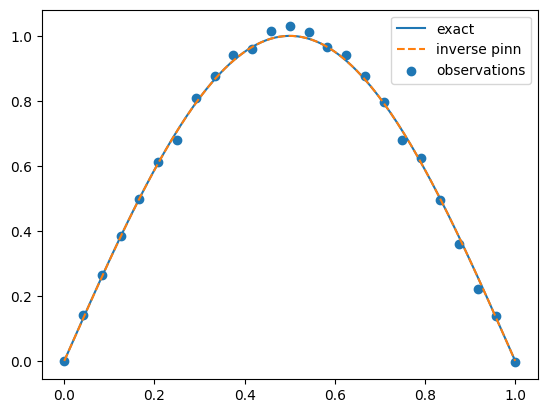

In [29]:
params_learned, lam_learned = theta

print("Learned lambda:", lam_learned)
print("True lambda:", pi**2)

u_pred = jax.vmap(lambda x: u_hard(params_learned, x))(x_plot)
u_exact = jnp.sin(pi*x_plot)

plt.plot(x_plot, u_exact, label="exact")
plt.plot(x_plot, u_pred, "--", label="inverse pinn")
plt.scatter(x_obs, u_obs, label="observations")
plt.legend()
plt.show()